<h1> Covid-19 Stats In the USA </h1> 

<h3> Introduction </h3>
The data set analysied in this project contains real world infromation regarding the COVID-19 vaccinations in the various states of the USA. The data consitutes of dates, numbers, and strings, making it suitable for anal ysis. The data set contains more then 10 columns and over 20,000 rows, ensuring it meets the requirements for size.

<h3> Data Exploration </h3>
The dataset consists of 54,628 entries and 16 columns. The columns include:

| Attribute                              | Description                                      |
|----------------------------------------|--------------------------------------------------|
| `ldate`                                | The date of the data entry                       |
| `location`                             | The state                                        |
| `total_vaccinations`                   | Total number of vaccinations                     |
| `total_distributed`                    | Total number of distributed vaccines             |
| `people_vaccinated`                    | Number of people vaccinated                      |
| `people_fully_vaccinated_per_hundred`  | Percentage of people fully vaccinated            |
| `total_vaccinations_per_hundred`       | Total vaccinations per hundred people            |
| `people_fully_vaccinated`              | Number of people fully vaccinated                |
| `people_vaccinated_per_hundred`        | Percentage of people vaccinated                  |
| `distributed_per_hundred`              | Distributed vaccines per hundred people          |
| `daily_vaccinations_raw`               | Raw count of daily vaccinations                  |
| `daily_vaccinations`                   | Adjusted count of daily vaccinations             |
| `daily_vaccinations_per_million`       | Daily vaccinations per million people            |
| `share_doses_used`                     | Share of doses used                              |
| `total_boosters`                       | Total number of booster shots                    |
| `total_boosters_per_hundred`           | Total boosters per hundred people                |

<h3> Plot 1: Barplot of Total Vaccinations by State </h3>

The Bar plot is a visual representation of the total number of vavinations admistered across the various different states of America. Each bar represents the total count of vaccinations for a particular state, arranged in decending order, providing a clear comparison between the states. The x-axis indicates the number of total vaccinations and the y-axis lists the states. This plot helps identifying the states which were the most and least practive in their vaccination campaigns. The use of the colour palette enhances the apeal and readability of thr chart. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'us_state_vaccinations.csv'


# Plot 1: Barplot of Total Vaccinations by State with increased spacing on y-axis
plt.figure(figsize=(15, 10))
total_vaccinations_by_state = vaccination_data_filtered.groupby('location')['total_vaccinations'].sum().sort_values(ascending=False)

ax = sns.barplot(x=total_vaccinations_by_state.values, y=total_vaccinations_by_state.index, palette='viridis')
plt.xlabel('Total Vaccinations (Number of Doses)')
plt.ylabel('State')
plt.title('Total Vaccinations by State')

# Increase the spacing between the states on the y-axis
for label in ax.get_yticklabels():
    label.set_y(label.get_position()[1] + 0.1)  # Increase the y position slightly for each label

plt.show()



NameError: name 'vaccination_data_filtered' is not defined

<Figure size 1500x1000 with 0 Axes>

<h3> Plot 2: Scatterplot of People Vaccinated vs. Total Distributed Vaccines </h3>
The scatter plot displys the realtionship between the total number of vaccines distriubted and the number of people vaccinated accores the USA. Each point representes a state on a specific date. The plot shows a positive correlation indicating that as more vaccines are distributed, more people are vaccinated, idciating a higher vaccination uptake as availability increases. 

X-axis: Total distributed vaccines
Y-axis: People Vaccinated


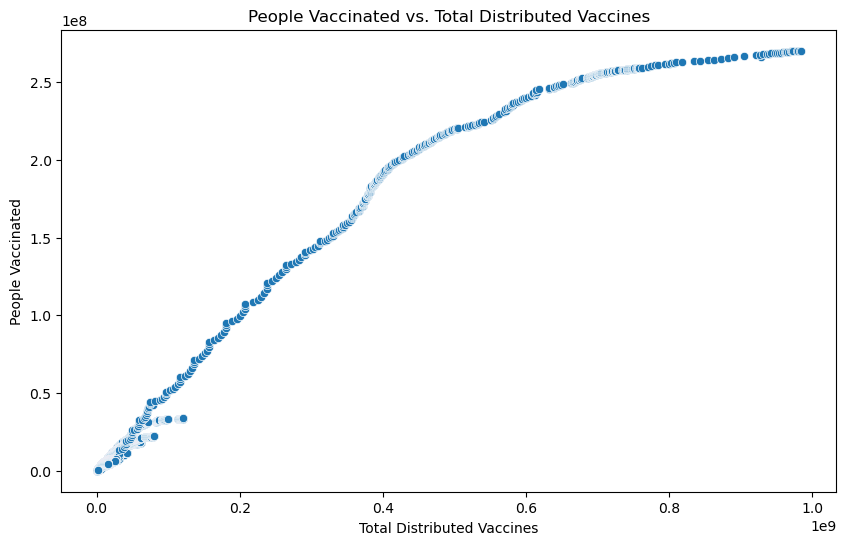

In [60]:
# Plot 2: Scatterplot of People Vaccinated vs. Total Distributed Vaccines
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_distributed', y='people_vaccinated', data=vaccination_data)
plt.xlabel('Total Distributed Vaccines')
plt.ylabel('People Vaccinated')
plt.title('People Vaccinated vs. Total Distributed Vaccines')
plt.show()


<h3>Plot 3: Scatterplot of People Vaccinated vs. Total Distributed Vaccines </h3>
The Pie plot displays the distribution of people who are fully vaccinayed amoungst the top 10 U.S states. Each section represents the portion of those fully vaccinated in each of these states relative to the total number of people fully vaccinated accorss the top ten states. In terms of population vaccination, the states with the biggest slices have made the most progress. This graphic presents a comparative analysis of vaccination programs across the top states, emphasizing those with the greatest immunization successes. 

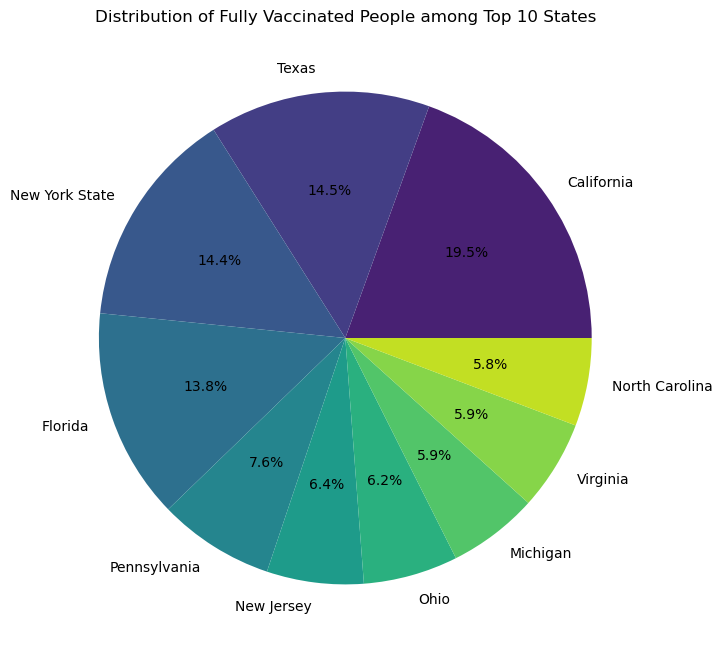

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'us_state_vaccinations.csv'


# Filter out the 'United States' entry
vaccination_data_filtered = vaccination_data[vaccination_data['location'] != 'United States']

# Group by location and sum the people fully vaccinated
fully_vaccinated_by_state = vaccination_data_filtered.groupby('location')['people_fully_vaccinated'].sum()

# Select the top 10 states with the most fully vaccinated people
top_10_fully_vaccinated_states = fully_vaccinated_by_state.sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 8))
top_10_fully_vaccinated_states.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette("viridis", 10))
plt.title('Distribution of Fully Vaccinated People among Top 10 States')
plt.ylabel('')
plt.show()



<h3> Plot 4: Correlation Heatmap </h3>
The correlation matrix of several numerical characteristics from the US state vaccines dataset is shown in this heatmap. Darker hues imply stronger correlations, and color intensity reflects correlation strength. Warm colors are used to represent positive correlations and cool colors are used to represent negative correlations. Attributes like {total_vaccinations}, {people_vaccinated}, and {total_distributed} show strong positive relationships, suggesting that these measures tend to rise together. There are no significant negative associations in this dataset, but if there were any, they would be displayed in blue. Lighter hues are used to depict attributes that have little or no link with one another. The correlations between various vaccination-related variables throughout the states can be found with the aid of this visualization.

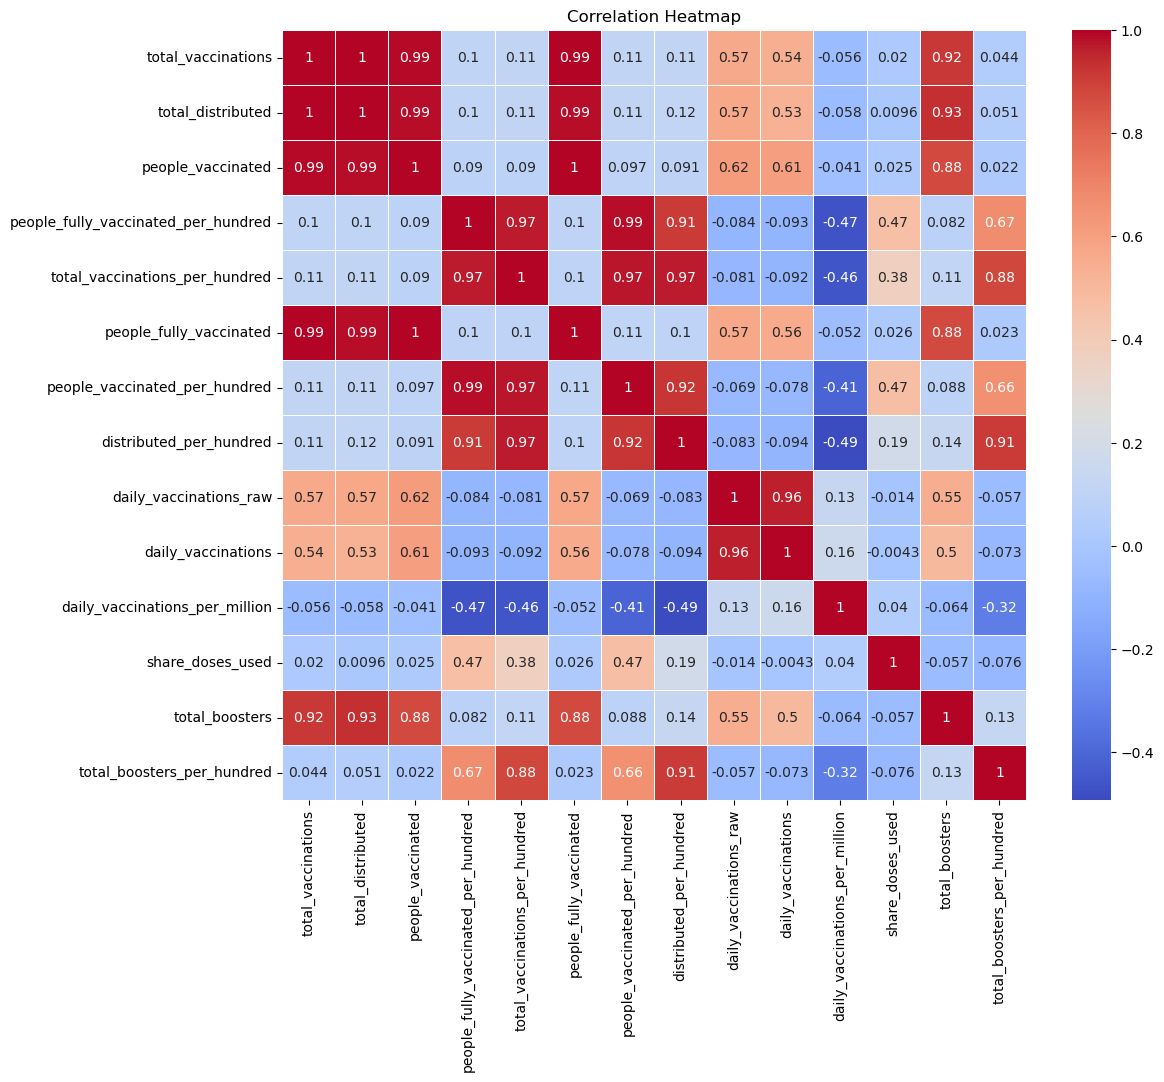

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'us_state_vaccinations.csv'


# Filter out non-numeric columns
numeric_data = vaccination_data.select_dtypes(include=[float, int])

# Compute the correlation matrix
corr_matrix = numeric_data.corr()

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()


<h3> Plot 5: Histogram of Daily Vaccinations per Million </h3>

This histogram illustrates the distribution of daily vaccinations per million people across various U.S. states. The data is divided into 30 bins, and a kernel density estimate (KDE) overlay provides a smooth representation of the data distribution. Data points below 5,000 daily vaccines per million show a considerable concentration of vaccinations, which is lower than in other states. The distribution is right-skewed, meaning that certain states have noticeably higher daily vaccination rates than the majority, which is indicative of relatively low rates in most states. Up to about 25,000 vaccines per million vaccinations per day, there is a significant drop in frequency at higher values.


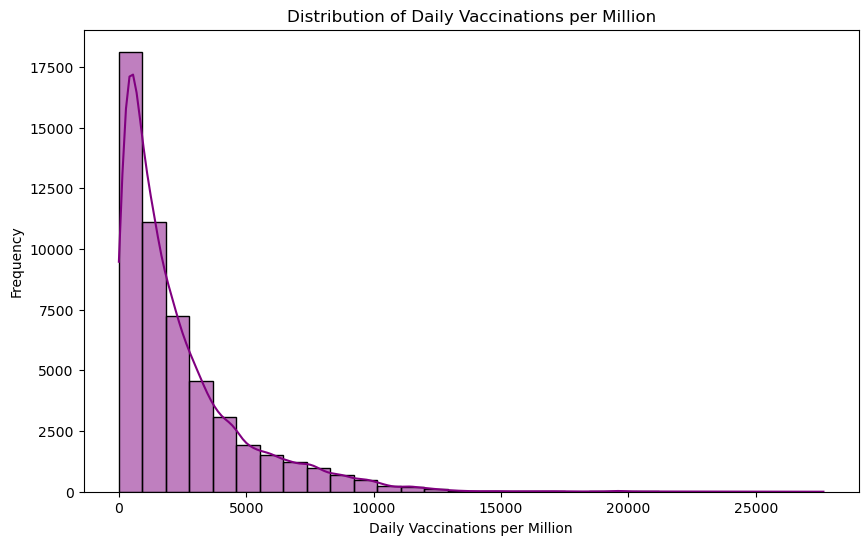

In [74]:

# Plot 5: Histogram of Daily Vaccinations per Million
plt.figure(figsize=(10, 6))
sns.histplot(vaccination_data['daily_vaccinations_per_million'], bins=30, kde=True, color='purple')
plt.xlabel('Daily Vaccinations per Million')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Vaccinations per Million')
plt.show()

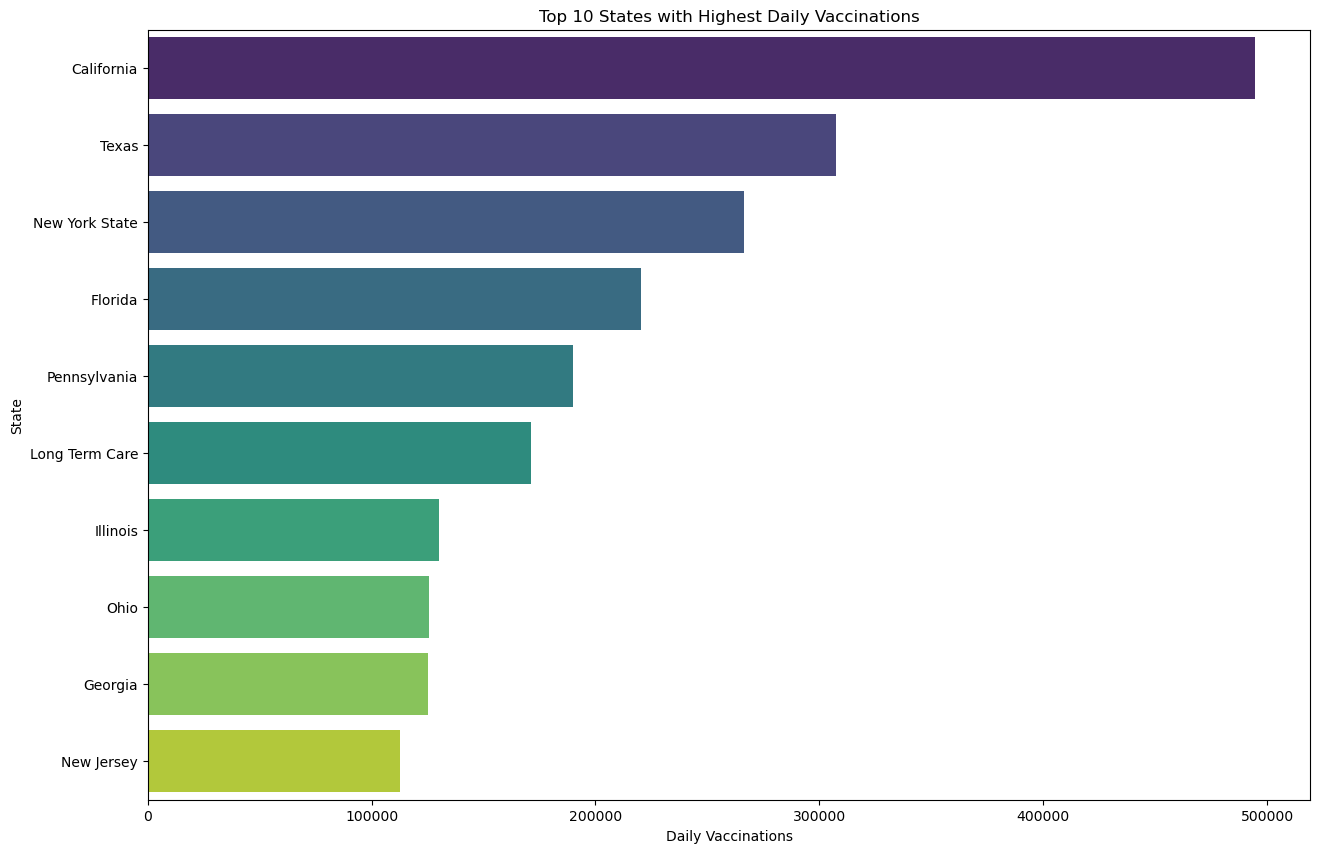

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'us_state_vaccinations.csv'

# Filter out the 'United States' entry
vaccination_data_filtered = vaccination_data[vaccination_data['location'] != 'United States']

# Plot 4: Horizontal Bar Plot of Top 10 States with Highest Daily Vaccinations
daily_vaccinations_by_state = vaccination_data_filtered.groupby('location')['daily_vaccinations'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(15, 10))
sns.barplot(x=daily_vaccinations_by_state.values, y=daily_vaccinations_by_state.index, palette='viridis')
plt.xlabel('Daily Vaccinations')
plt.ylabel('State')
plt.title('Top 10 States with Highest Daily Vaccinations')
plt.show()
